# Getting the Weather Data

In [1]:
import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
url = "https://dataset.api.hub.geosphere.at/v1/station/historical/tawes-v1-10min/metadata"

In [357]:
base_url ="https://dataset.api.hub.geosphere.at/v1"

## Getting all stations

In [96]:
datasets = requests.get(base_url + "/datasets")

In [97]:
datasets.json()

{'/grid/historical/apolis_short-v1-1d-100m': {'type': 'grid',
  'mode': 'historical',
  'response_formats': ['geojson', 'netcdf'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/grid/historical/apolis_short-v1-1d-100m'},
 '/timeseries/historical/apolis_short-v1-1d-100m': {'type': 'timeseries',
  'mode': 'historical',
  'response_formats': ['geojson', 'csv'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/timeseries/historical/apolis_short-v1-1d-100m'},
 '/station/historical/histalp-v1-1y': {'type': 'station',
  'mode': 'historical',
  'response_formats': ['geojson', 'csv'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/station/historical/histalp-v1-1y'},
 '/grid/historical/inca-v1-1h-1km': {'type': 'grid',
  'mode': 'historical',
  'response_formats': ['geojson', 'netcdf'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/grid/historical/inca-v1-1h-1km'},
 '/timeseries/historical/inca-v1-1h-1km': {'type': 'timeseries',
  'mode': 'historical',
  'response_formats': ['geojson'

In [358]:
stations = requests.get(base_url + "/station/historical/klima-v2-1h/metadata")

In [40]:
stations.json()

{'stations': [{'type': 'COMBINED',
   'id': 1,
   'group_id': None,
   'name': 'Aflenz',
   'state': 'Steiermark',
   'lat': 47.54594,
   'lon': 15.24069,
   'altitude': 783.2,
   'valid_from': '1983-05-01T00:00:00+00:00',
   'valid_to': '2100-12-31T00:00:00+00:00',
   'has_sunshine': True,
   'has_global_radiation': True,
   'is_active': True},
  {'type': 'COMBINED',
   'id': 2,
   'group_id': None,
   'name': 'Aigen im Ennstal',
   'state': 'Steiermark',
   'lat': 47.53278,
   'lon': 14.13826,
   'altitude': 641.0,
   'valid_from': '1993-02-01T00:00:00+00:00',
   'valid_to': '2100-12-31T00:00:00+00:00',
   'has_sunshine': True,
   'has_global_radiation': True,
   'is_active': True},
  {'type': 'COMBINED',
   'id': 3,
   'group_id': None,
   'name': 'Allentsteig',
   'state': 'Niederösterreich',
   'lat': 48.69083,
   'lon': 15.36694,
   'altitude': 598.8,
   'valid_from': '1992-10-01T00:00:00+00:00',
   'valid_to': '2100-12-31T00:00:00+00:00',
   'has_sunshine': True,
   'has_global_

In [168]:
stmk = []
sbg = []
w = []
oe = []
inn = []

In [169]:
#Sorting stations by state
for station in stations.json()["stations"]:
    if station["state"] == "Tirol":
        inn.append(station)
    elif station["state"] == "Salzburg":
        sbg.append(station)
    elif station["state"] == "Oberösterreich":
        oe.append(station)
    elif station["state"] == "Wien":
        w.append(station)
    elif station["state"] == "Steiermark":
        stmk.append(station)

In [182]:
#Graz Universität/Heinrichstraße had 50% missing values. Searching for other stations in Graz
stat_graz = []
for stat in stmk:
    if "Graz" in stat["name"]:
        stat_graz.append(stat)

In [214]:
#Salzburg Freisaal had 100% missing values in Snow amount measurement
stat_sbg = []
for stat in sbg:
    if "Salzburg" in stat["name"]:
        stat_sbg.append(stat)

In [216]:
stat_sbg

[{'type': 'COMBINED',
  'id': 131,
  'group_id': None,
  'name': 'Salzburg Flughafen',
  'state': 'Salzburg',
  'lat': 47.78944,
  'lon': 13.00861,
  'altitude': 430.0,
  'valid_from': '1939-03-01T00:00:00+00:00',
  'valid_to': '2100-12-31T00:00:00+00:00',
  'has_sunshine': True,
  'has_global_radiation': False,
  'is_active': True},
 {'type': 'COMBINED',
  'id': 145,
  'group_id': None,
  'name': 'Salzburg Freisaal',
  'state': 'Salzburg',
  'lat': 47.79111,
  'lon': 13.05417,
  'altitude': 419.0,
  'valid_from': '1987-01-01T00:00:00+00:00',
  'valid_to': '2100-12-31T00:00:00+00:00',
  'has_sunshine': True,
  'has_global_radiation': True,
  'is_active': True},
 {'type': 'INDIVIDUAL',
  'id': 6300,
  'group_id': 131,
  'name': 'Salzburg Flughafen',
  'state': 'Salzburg',
  'lat': 47.78944,
  'lon': 13.00861,
  'altitude': 430.0,
  'valid_from': '1933-09-01T00:00:00+00:00',
  'valid_to': '2100-12-31T00:00:00+00:00',
  'has_sunshine': True,
  'has_global_radiation': False,
  'is_active':

Searched for weather stations in austrias biggest citys because they will have data that impacts many people thus probably being most corellated to the austrian average energy consumption 

In [359]:
station_graz = "Graz Thalerhof Flughafen"
station_sbg = "Salzburg Freisaal"
staion_oö = "Linz Stadt"
station_inn = "Innsbruck Universität"
station_w = "Wien Hohe Warte"

In [360]:
stationen = [station_graz, station_sbg, staion_oö, station_inn, station_w]

In [361]:
stationen

['Graz Thalerhof Flughafen',
 'Salzburg Freisaal',
 'Linz Stadt',
 'Innsbruck Universität',
 'Wien Hohe Warte']

In [369]:
stadt_und_ids = {}
for station in stationen:
    stadt_und_ids[station] = []

In [370]:
for station in stations.json()["stations"]:
    if station["name"] in stationen:
        stadt_und_ids[station["name"]].append(station["id"])

In [371]:
stadt_und_ids

{'Graz Thalerhof Flughafen': [16400],
 'Salzburg Freisaal': [145, 6304, 6305],
 'Linz Stadt': [56, 3202],
 'Innsbruck Universität': [39, 11801, 11803],
 'Wien Hohe Warte': [105, 5901, 5904]}

## Getting the hourly Data for each relevant station from 2019-2025

In [100]:
metadata = requests.get(base_url + "/station/historical/klima-v2-1h/metadata")

The Metadata Resonse contains all the information: stations, features...

In [102]:
metadata.json()["parameters"]

[{'name': 'cglo',
  'long_name': 'Globalstrahlung Mittelwert',
  'description': 'Globalstrahlung, kalibrierter Stunden-Mittelwert',
  'unit': 'W/m²'},
 {'name': 'cglo_flag',
  'long_name': 'Qualitätsflag für Globalstrahlung Mittelwert',
  'description': 'Qualitätsflag für Globalstrahlung, kalibrierter Stunden-Mittelwert',
  'unit': 'code',
  'code_list_ref': 'q21'},
 {'name': 'dd',
  'long_name': 'Windrichtung 360° Mittelwert',
  'description': 'Windrichtung [360°], vektorieller Stunden-Mittelwert',
  'unit': '°'},
 {'name': 'dd_flag',
  'long_name': 'Qualitätsflag für Windrichtung 360° Mittelwert',
  'description': 'Qualitätsflag für Windrichtung [360°], vektorieller Stunden-Mittelwert',
  'unit': 'code',
  'code_list_ref': 'q21'},
 {'name': 'ddx',
  'long_name': 'Windrichtung zur Spitzenböe',
  'description': 'Windrichtung der maximalen Windgeschwindigkeit (Spitzenböe), Stundenwert',
  'unit': '°'},
 {'name': 'ddx_flag',
  'long_name': 'Qualitätsflag für Windrichtung zur Spitzenböe',

## Beschreibung der Parameter:
"ff" : "Windgeschwindigkeit", 

"rr": "Niederschlag",  

"sh": "Gesamtschneehöhe", 

"so_h": "Sonnenscheindauer", 

"tl": "Lufttemperatur"

In [365]:
def get_station_data(station_id, start = "2019-01-01T00:00", end = "2025-09-30T23:00"):
    try:
        print("Fetching Data")
        response = requests.get("https://dataset.api.hub.geosphere.at/v1/station/historical/klima-v2-1h", 
                    params = {
                        "parameters": ["ff", "rr", "sh", "so_h", "tl"],
                        "start": start,
                        "end": end,
                        "station_ids": station_id
                            })
        print("Parsing Result")
        data = response.json()
        print("Transforming Results")
        timestamps = data["timestamps"]
        params = data["features"][0]["properties"]["parameters"]
        print("Creating Params Dict")
        params_dict = {k: v["data"] for k, v in params.items()}
        return timestamps, params_dict

    except Exception as e:
        print(e)

In [366]:
def create_data_frame(station_id, start = "2019-01-01T00:00", end = "2025-09-30T23:00"):
    timestamps, params_dict = get_station_data(station_id, start, end)
    print("Creating DataFrame")
    df = pd.DataFrame(params_dict, index = pd.to_datetime(timestamps))
    print("Success")
    return df

In [367]:
def save_data_frame(df, df_name):
    if not os.path.exists("./weather_data"):
        os.makedirs("./weather_data")
    df.to_csv(f"./weather_data/{str(df_name)}.csv")

In [242]:
save_data_frame(create_data_frame(stadt_und_ids["Salzburg Freisaal"][0]), "Salzburg")

Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success


In [372]:
for k, v in stadt_und_ids.items():
    print(k)
    save_data_frame(create_data_frame(v[0]), k)
    print(f"Successfully saved Data_Frame for {k}")

Graz Thalerhof Flughafen
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Graz Thalerhof Flughafen
Salzburg Freisaal
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Salzburg Freisaal
Linz Stadt
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Linz Stadt
Innsbruck Universität
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Innsbruck Universität
Wien Hohe Warte
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Wien Hohe Warte


## Initial Exploring of the Data.

In [373]:
def prepare_data_frame(df):
    df = df.rename(columns = {"Unnamed: 0": "DateUTC"})
    df["DateUTC"] = pd.to_datetime(df["DateUTC"])
    df = df.set_index("DateUTC")
    if "sh" in df.columns:
        df = df.drop(columns=["sh"])
    return df

1. Daten Exploren: Missing Values plotten
2. Daten brauchbar machen: Nan bei Schneefall => 0. Bei anderen rolling_mean...

In [389]:
Wien = prepare_data_frame(pd.read_csv("./weather_data/Wien Hohe Warte.csv"))
Salzburg = prepare_data_frame(pd.read_csv("./weather_data/Salzburg Freisaal.csv"))
Graz = prepare_data_frame(pd.read_csv("./weather_data/Graz Thalerhof Flughafen.csv"))
Innsbruck = prepare_data_frame(pd.read_csv("./weather_data/Innsbruck Universität.csv"))
Linz = prepare_data_frame(pd.read_csv("./weather_data/Linz Stadt.csv"))

In [379]:
cities = [Wien, Salzburg, Graz, Innsbruck, Linz]

In [380]:
city_names = ["Wien", "Salzburg", "Graz", "Innsbruck", "Linz"]

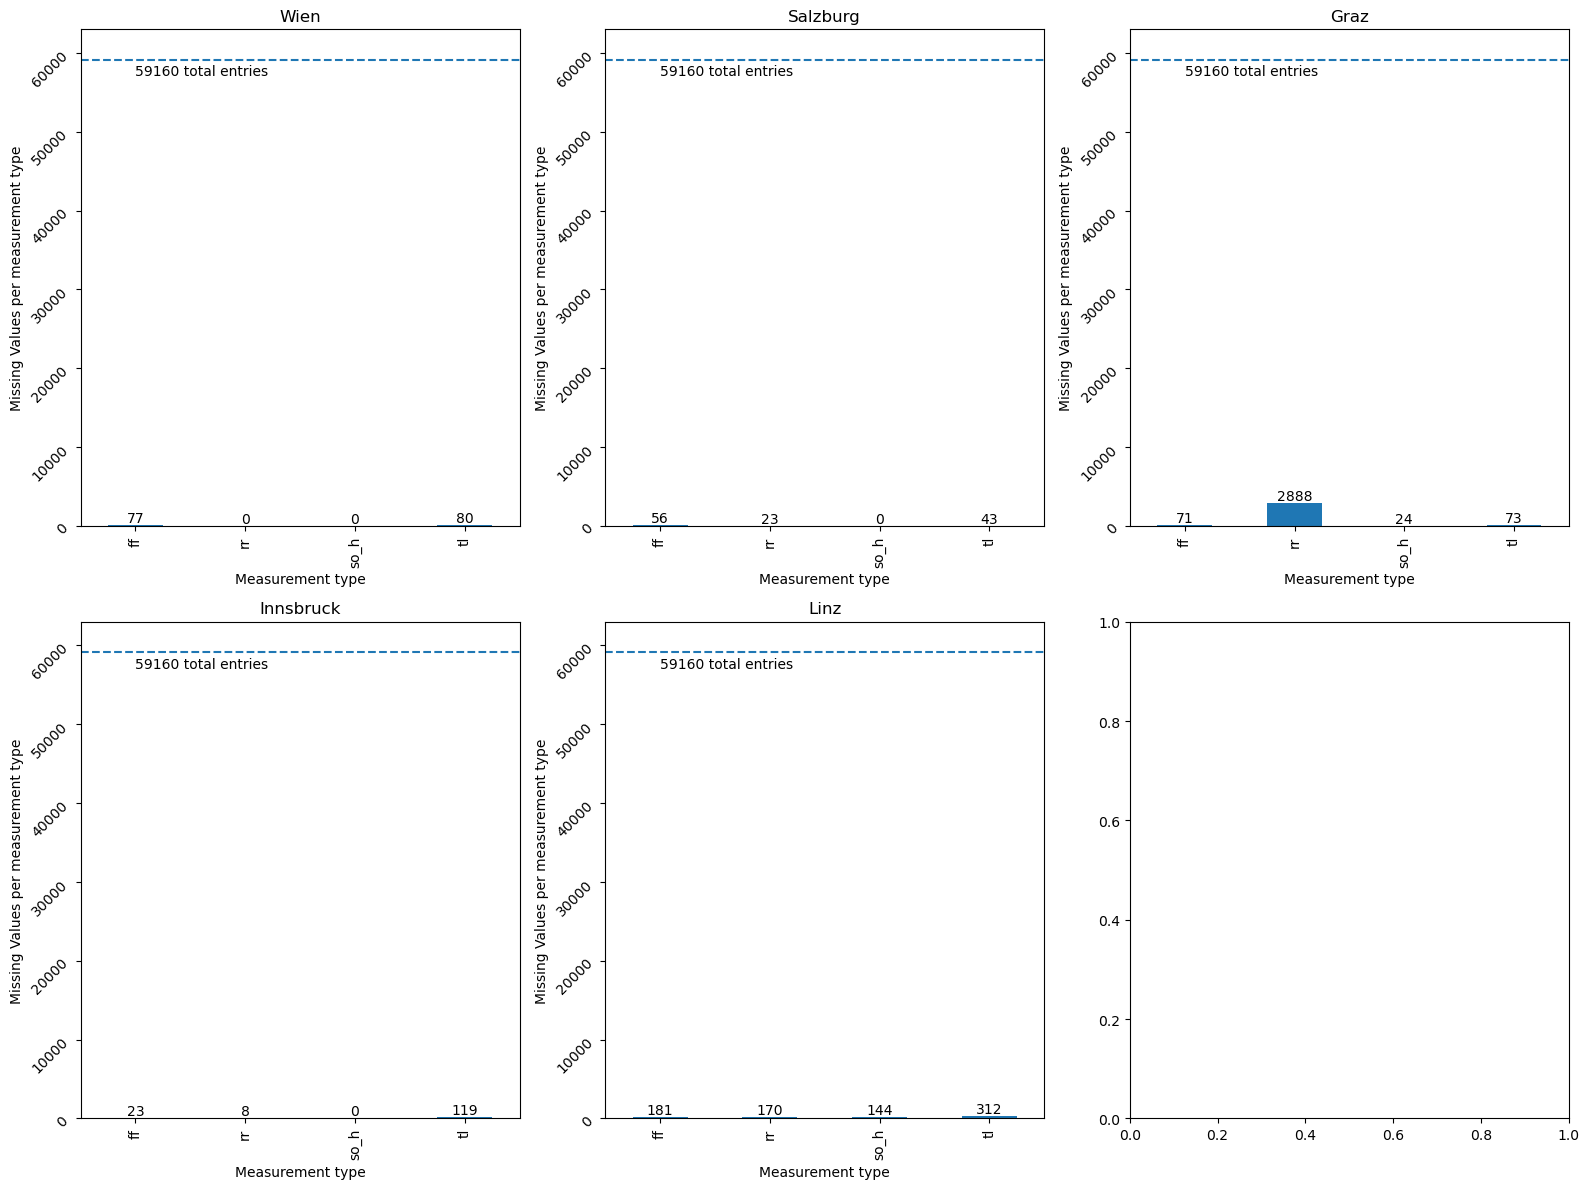

In [381]:
plt.subplots(2, 3, figsize = (16, 12))
for i, city in enumerate(cities):
    plt.subplot(2, 3, i+1)
    ax = city.isna().sum().plot(kind = "bar")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.f")
    plt.title(city_names[i])
    plt.axhline(len(city), 0,  linestyle = "--")
    plt.text(0, len(city)-2000, f"{len(city)} total entries")
    plt.xlabel("Measurement type")
    plt.ylabel("Missing Values per measurement type")
    plt.tick_params("y", rotation = 45)
    plt.tight_layout()
    plt.ylim(0, 63000)
    plt.savefig("Missing Values by City")

## Handling Missing Values

In [392]:
def handle_missing_inputs(dfs):
    rr_median = pd.concat([rain_df["rr"] for rain_df in dfs], axis = 1).median(axis = 1)
    
    for df in dfs:
        df["so_h"] = df["so_h"].fillna(
            pd.concat([df["so_h"].shift(-24), df["so_h"].shift(24)], axis = 1).mean(axis = 1)
        )
        df["ff"] = df["ff"].fillna(
            pd.concat([df["ff"].shift(24), df["ff"].shift(1), df["ff"].shift(-24), df["ff"].shift(-1)], axis = 1).mean(axis = 1)
        )
        df["rr"] = df["rr"].fillna(
            pd.concat([df["rr"].shift(24), df["rr"].shift(-24), df["rr"].rolling(window = 3, min_periods = 1).mean()], axis = 1).mean(axis=1)
        )
        if not df["rr"].isna().sum() == 0:
            df["rr"] = df["rr"].fillna(rr_median)
        df["tl"] = df["tl"].fillna(
            pd.concat([df["tl"].shift(48), df["tl"].shift(-48), df["tl"].shift(24), df["tl"].shift(-24), df["tl"].shift(1), df["tl"].shift(-1)], axis = 1).mean(axis=1)
        )
    return dfs

In [393]:
cities = handle_missing_inputs(cities)

In [394]:
for city in cities:
    print(city.isna().sum())

ff      0
rr      0
so_h    0
tl      0
dtype: int64
ff      0
rr      0
so_h    0
tl      0
dtype: int64
ff      0
rr      0
so_h    0
tl      0
dtype: int64
ff      0
rr      0
so_h    0
tl      0
dtype: int64
ff      0
rr      0
so_h    0
tl      0
dtype: int64


## Handle Outliers

In [395]:
def re_evaluate_outliers(dfs):
    for df in dfs:
        for cat in df.columns:
            outliers = df.loc[df[cat] > df[cat].quantile(0.9999), cat]
            timestamps = outliers.index
            values = []
            for ts in timestamps:
                values.append(df.loc[ts-pd.Timedelta(hours=1) : ts+pd.Timedelta(hours=1), cat].mean())
            df.loc[df[cat] > df[cat].quantile(0.9999), cat] = values
    return dfs

In [396]:
cities = re_evaluate_outliers(cities)

## Further Exploration

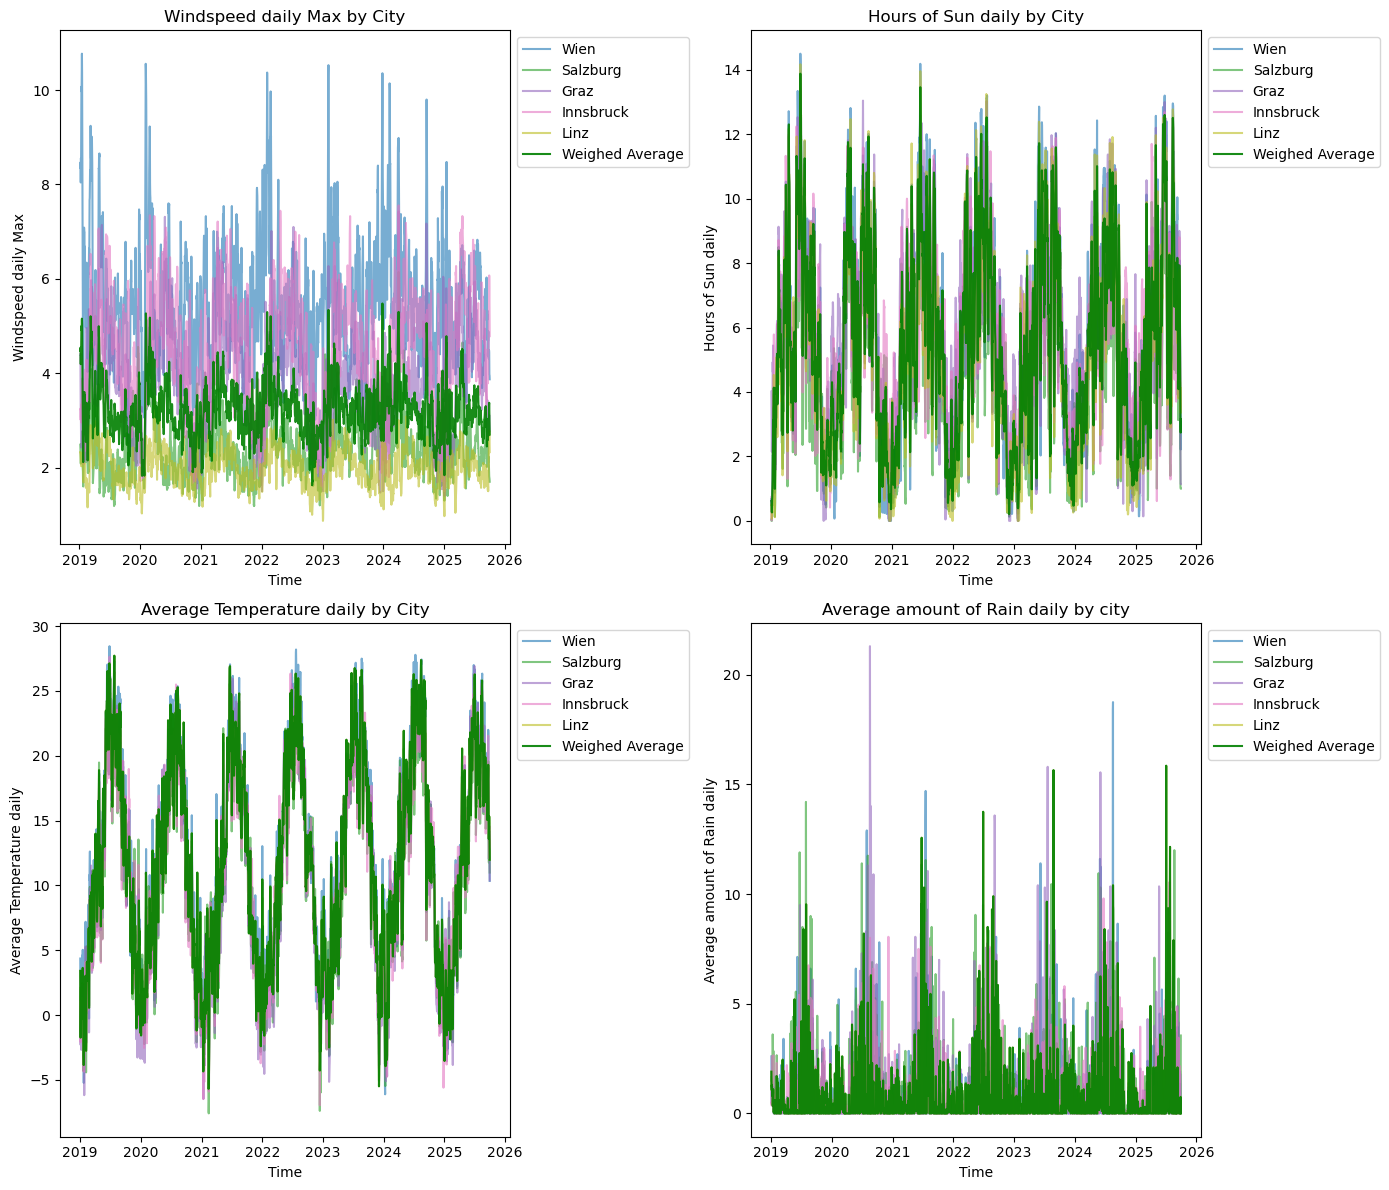

In [436]:
#Make sure to run the code to create the merged_data DataFrame further below, or comment out the code that creates the merged_data plots
plt.subplots(2,2, figsize=(14,12))
plt.subplot(2,2, 1)           
for df, label, color in zip(cities, city_names, [f"C{i*2}" for i in range(len(cities))]):
    daily_max = df["ff"].resample("D").max().rolling(7).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.6, color = color)

#Also plot a line for the merged_data
daily_max = merged_data["ff"].resample("D").max().rolling(7).mean()
plt.plot(daily_max.index, daily_max, label = "Weighed Average", alpha=0.9, color = "green")


plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Windspeed daily Max by City")
plt.xlabel("Time")
plt.ylabel(f"Windspeed daily Max")
plt.tight_layout()

plt.subplot(2,2, 2)
for df, label, color in zip(cities, city_names, [f"C{i*2}" for i in range(len(cities))]):
    daily_max = df["so_h"].resample("D").sum().rolling(7).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.6, color = color)

#Also plot a line for the merged_data
daily_max = merged_data["so_h"].resample("D").sum().rolling(7).mean()
plt.plot(daily_max.index, daily_max, label = "Weighed Average", alpha=0.9, color = "green")

plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Hours of Sun daily by City")
plt.xlabel("Time")
plt.ylabel(f"Hours of Sun daily")
plt.tight_layout()

plt.subplot(2,2, 3)     
for df, label, color in zip(cities, city_names, [f"C{i*2}" for i in range(len(cities))]):
    daily_max = df["tl"].resample("D").mean().rolling(2).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.6, color = color)

#Also plot a line for the merged_data
daily_max = df["tl"].resample("D").mean().rolling(2).mean()
plt.plot(daily_max.index, daily_max, label = "Weighed Average", alpha=0.9, color = "green")

plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Average Temperature daily by City")
plt.xlabel("Time")
plt.ylabel(f"Average Temperature daily")
plt.tight_layout()


plt.subplot(2,2, 4)
for df, label, color in zip(cities, city_names, [f"C{i*2}" for i in range(len(cities))]):
    daily_max = df["rr"].resample("D").max().rolling(2).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.6, color = color)
#Also plot a line for the merged_data
daily_max = df["rr"].resample("D").max().rolling(2).mean()
plt.plot(daily_max.index, daily_max, label = "Weighed Average", alpha=0.9, color = "green")

plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Average amount of Rain daily by city")
plt.xlabel("Time")
plt.ylabel(f"Average amount of Rain daily")
plt.tight_layout()

plt.savefig("Windspeed, Hours, Temperature, Rain Daily by City")
plt.show()


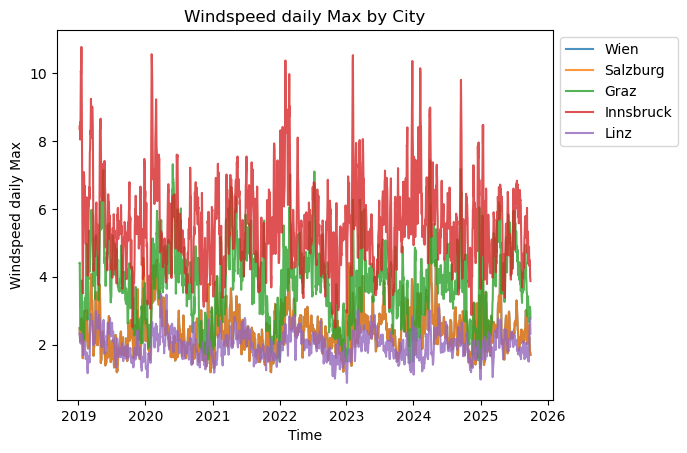

In [291]:
for df, label, color in zip(cities, city_names, [f"C{i}" for i in range(len(cities))]):
    daily_max = df["ff"].resample("D").max().rolling(7).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.8, color = color)

plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Windspeed daily Max by City")
plt.xlabel("Time")
plt.ylabel(f"Windspeed daily Max")
plt.savefig("Daily Max Windspeed by City", bbox_inches="tight")
plt.show()

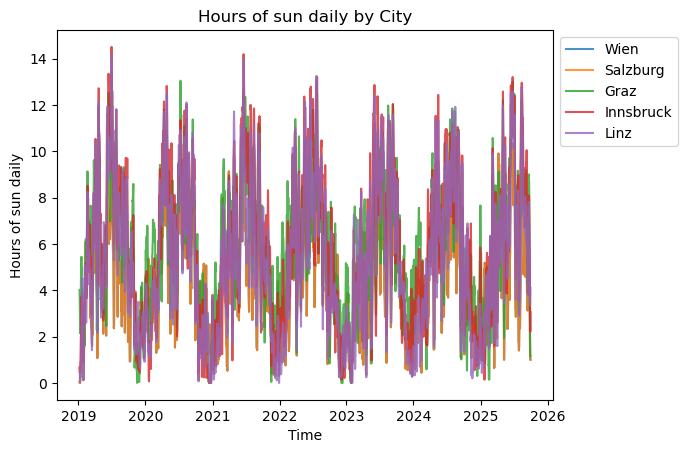

In [288]:
for df, label, color in zip(cities, city_names, [f"C{i}" for i in range(len(cities))]):
    daily_max = df["so_h"].resample("D").sum().rolling(7).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.8, color = color)

plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Hours of sun daily by City")
plt.xlabel("Time")
plt.ylabel(f"Hours of sun daily")
plt.savefig("Hours of sun daily by City", bbox_inches="tight")
plt.show()

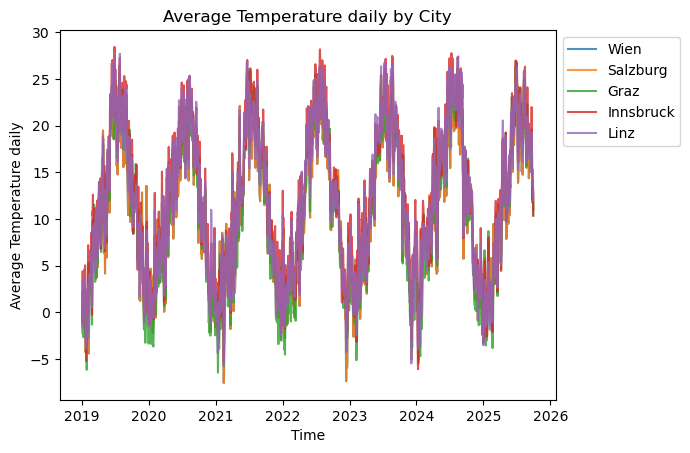

In [289]:
for df, label, color in zip(cities, city_names, [f"C{i}" for i in range(len(cities))]):
    daily_max = df["tl"].resample("D").mean().rolling(2).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.8, color = color)

plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Average Temperature daily by City")
plt.xlabel("Time")
plt.ylabel(f"Average Temperature daily")
plt.savefig("Daily Average Temperature by City", bbox_inches="tight")
plt.show()

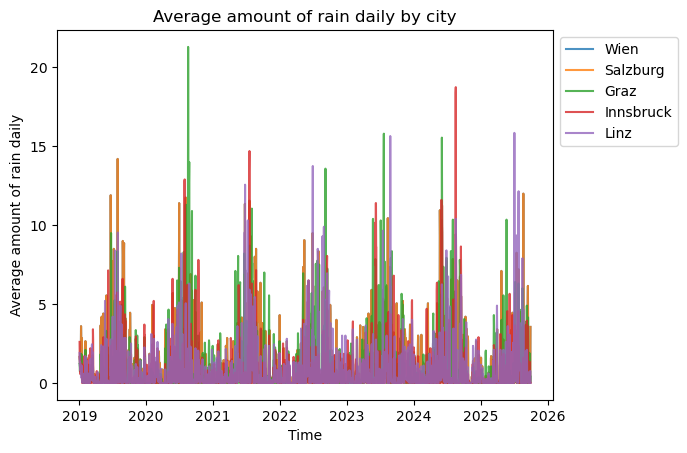

In [290]:
for df, label, color in zip(cities, city_names, [f"C{i}" for i in range(len(cities))]):
    daily_max = df["rr"].resample("D").max().rolling(2).mean()
    plt.plot(daily_max.index, daily_max, label = label, alpha=0.8, color = color)

plt.legend(bbox_to_anchor=(1, 1))
plt.title(f"Average amount of rain daily by city")
plt.xlabel("Time")
plt.ylabel(f"Average amount of rain daily")
plt.savefig("Average amount of rain daily by city", bbox_inches="tight")
plt.show()

# Create Features

Energy Forecast is for Austria in general, so the Data of the 5 weather stations will be averaged to resemble austria. The average will be weighed according to population per city.

Features will then be created:
1. Temperature
2. Temperature(24h avg)
3. Temperature(72h avg) Energy consumption probably lags behind because buildings cool off/heat up slower
4. Sun Hours
5. Sun Hours (24h avg) Indicates Solar energy use
6. Rain
7. Wind
8. HeatingDegree (Indicates how likely it is, that heating is needed and how much heating is needed, by checking how much the temp differs to comfortable temp)
9. CoolingDegree (Indicates how likely it is, that cooling is needed and how much cooling is needed, by checking how much the temp differs to comfortable temp)

In [398]:
#Rounded inhabitants of the respective states to the big citys. Data would have been skewed too hard to vienna otherwise
pop_w = 2000000
pop_g = 120000
pop_s = 570000
pop_l = 1500000
pop_i = 780000

In [399]:
pop_ges = pop_w + pop_g + pop_s + pop_l + pop_i

In [400]:
pop_ges

4970000

In [401]:
merged_data = pd.concat(
    [Wien*(pop_w/pop_ges), Graz*(pop_g/pop_ges), Salzburg*(pop_s/pop_ges), Linz*(pop_l/pop_ges), Innsbruck*(pop_i/pop_ges)]
).groupby(level = 0).sum()

In [423]:
merged_data["temp_24h"] = merged_data["tl"].rolling(window = 24).mean()
merged_data["temp_72h"] = merged_data["tl"].rolling(window = 72).mean()
merged_data["sun_24h"] = merged_data["so_h"].rolling(window = 24).mean()
merged_data["hdg"] = 19 - merged_data["tl"]
merged_data["cdg"] =  merged_data["tl"] - 23

In [443]:
merged_data = merged_data.dropna()

In [444]:
merged_data.head()

,ff,rr,so_h,tl,temp_24h,temp_72h,sun_24h,hdg,cdg
DateUTC,,,,,,,,,
2019-01-03 23:00:00+00:00,3.269618,0.192555,0.0,-2.472233,-1.504670,1.626193,0.008317,21.472233,-25.472233
2019-01-04 00:00:00+00:00,2.943058,0.111670,0.0,-2.763984,-1.544660,1.549522,0.008317,21.763984,-25.763984
2019-01-04 01:00:00+00:00,2.890543,0.242052,0.0,-3.276258,-1.605558,1.464892,0.008317,22.276258,-26.276258
2019-01-04 02:00:00+00:00,2.459557,0.070020,0.0,-3.130785,-1.654368,1.376149,0.008317,22.130785,-26.130785
2019-01-04 03:00:00+00:00,2.311670,0.038632,0.0,-3.280282,-1.707378,1.280760,0.008317,22.280282,-26.280282


In [445]:
if not os.path.exists("./weather_data"):
    os.makedirs("./weather_data")

In [446]:
merged_data.to_csv("./weather_data/weather_data.csv")